# Introduction to Scikit-Learn (sklearn)

This notebook demonstrates some of the most useful functions of the
beautiful Scikit-Learn library.

What we're going to cover:

0. An end-to-end Scikit-Learn workflow
1. Getting the data ready
2. Choose the right estimator (model) / algorithm for our problems
3. Fit the model/algorithm and use it to make predictions on our data
4. Evaluating a model
5. Improve a model
6. Save and load a trained model
7. Putting it all together

## 0. An end-to-end Scikit-Learn workflow

In [1]:
# 1. Get the data ready
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

heart_disease = pd.read_csv('./data/heart-disease.csv')
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [2]:
# Create `X` (the "feature matrix")
# AKA data or feature variables
X = heart_disease.drop('target', axis=1)
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [3]:
# Create the y (AKA labels or label matrix)
y = heart_disease['target']
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

## 2. Choose the right model and hyperparameters

In [4]:
# Remember, "hyperparameters" are like "dials" we can use to (fine) tune our model
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

# We'll keep the default hyperparameters
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

## 3. Fit the model to the training data

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
clf.fit(X_train, y_train);

In [7]:
# Make a (faulty) prediction (using **incorrectly shaped** data)
try:
    y_broken_label = clf.predict(np.array([0, 2, 3, 4]))
except Exception as e:
    print(f'Exception: {type(e).__name__}: {e}')

Exception: ValueError: Expected 2D array, got 1D array instead:
array=[0. 2. 3. 4.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [8]:
# Make a (correct) prediction (using **correctly shaped** data)
# Note: we are still on step 3 or our workflow
y_label = clf.predict(X_test)

In [9]:
y_preds = clf.predict(X_test)
y_preds

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1])

In [10]:
y_test

192    0
295    0
200    0
288    0
163    1
      ..
119    1
133    1
87     1
294    0
73     1
Name: target, Length: 61, dtype: int64

## 4. Evaluate the model on the training data ...

In [11]:
clf.score(X_train, y_train)

1.0

In [12]:
# ... and on the test data
clf.score(X_test, y_test)

0.819672131147541

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test, y_preds))  # clf.predict(X_test)

              precision    recall  f1-score   support

           0       0.81      0.78      0.79        27
           1       0.83      0.85      0.84        34

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



See the article, [Understanding a Classification Report](https://medium.com/@kohlishivam5522/understanding-a-classification-report-for-your-machine-learning-model-88815e2ce397),
for an explanation of this report.

In [14]:
# Calculate the "confusion matrix" for test and predicted values
confusion_matrix(y_test, y_preds)

array([[21,  6],
       [ 5, 29]])

In [15]:
accuracy_score(y_test, y_preds)

0.819672131147541

## 5. Improve a model

In [16]:
# - Generate a one-time 128-bit secret for the seed.
import secrets

seed = secrets.randbits(128)
seed

157409740503572734599983279086145501111

In [17]:
# **Copy and paste** this value as the **hard-coded** random number
# generator seed
rng = np.random.default_rng(seed=77708057215789171477656921825058000355)

In [18]:
# Try different amount of `n_estimators`
for i in range(10, 100, 10):
    print(f'Trying model with {i} estimators...')
    # I use the `default_rng` with a specified seed to generate reproducible results.
    # The maximum integer I want is the largest unsigned 32-bit integer. (This value
    # is the largest value compatible with the argument to `rng.integers`.)
    clf = RandomForestClassifier(
        n_estimators=i,
        random_state=rng.integers(np.iinfo(np.uint32).max)).fit(X_train, y_train)
    print(f'Model accuracy on test set: {clf.score(X_test, y_test) * 100:.2f}%')
    print('')  # simply to separate runs

Trying model with 10 estimators...
Model accuracy on test set: 75.41%

Trying model with 20 estimators...
Model accuracy on test set: 80.33%

Trying model with 30 estimators...
Model accuracy on test set: 80.33%

Trying model with 40 estimators...
Model accuracy on test set: 78.69%

Trying model with 50 estimators...
Model accuracy on test set: 86.89%

Trying model with 60 estimators...
Model accuracy on test set: 81.97%

Trying model with 70 estimators...
Model accuracy on test set: 81.97%

Trying model with 80 estimators...
Model accuracy on test set: 83.61%

Trying model with 90 estimators...
Model accuracy on test set: 80.33%



The maximum accuracy of the test set, 91.80%, occurs with 50 estimators.

Consequently, we can **improve** our model by using 50 estimators.

## 6. Save and load a trained model

In [19]:
# We can save a model using `pickle`.
import pickle

In [20]:
# The video calls `pickle.dump(clf, open('random_forest_model.pkl', 'wb'))`.
# This call results in a type warning similar to
# "Expected SupportsWrite but got BinaryIO".
# This situation is resolved by using `with` below.

with open('./random_forest_model_1.pkl', 'wb') as f:
    pickle.dump(clf, f)

In [21]:
# What happens if we try to import the saved model.
with open('./random_forest_model_1.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [22]:
loaded_model.score(X_test, y_test)

0.8032786885245902

This result is the **same** as the last model we tried (90 estimators). **Hooray!**

In [23]:
# Let's "listify" the contents
what_were_covering = [
    '0. An end-to-end Scikit-Learn workflow',
    '1. Getting the data ready',
    '2. Choose the right estimator/algorithm/model for your problem',
    '3. Fitting your chosen machine learning model to data and using it to make a prediction',
    '4. Evaluating a machine learning model',
    '5. Improving predictions through experimentation (hyperparameter tuning)',
    '6. Saving and loading a pre-trained model',
    '7. Putting it all together in a pipeline',
]

In [24]:
what_were_covering

['0. An end-to-end Scikit-Learn workflow',
 '1. Getting the data ready',
 '2. Choose the right estimator/algorithm/model for your problem',
 '3. Fitting your chosen machine learning model to data and using it to make a prediction',
 '4. Evaluating a machine learning model',
 '5. Improving predictions through experimentation (hyperparameter tuning)',
 '6. Saving and loading a pre-trained model',
 '7. Putting it all together in a pipeline']

In [25]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline

## 1. Getting our data ready to be used with machine learning

Three main tasks to complete:

1. Split the data into features and labels (usually `X` and `y`)
2. Filling (AKA imputing) or disregarding missing values
3. Converting non-numerical values to numerical values (also called "feature encoding")

In [26]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [27]:
# The last column is our data to be predicted so we drop it
# Remember that `axis=1` is the **column** axis
# (`axis=0` is the **row** axis)
X = heart_disease.drop('target', axis=1)
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [28]:
y = heart_disease['target']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [29]:
# Split the features and labels into training and test splits
# We reserve 20% of our data for testing. This amount is "negotiable" for
# different problems.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [30]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [31]:
X.shape

(303, 13)

In [32]:
len(heart_disease)

303

In [33]:
len(heart_disease) * 0.8

242.4

In [34]:
242 + 61

303

In [35]:
len(heart_disease)

303

### 1.1 Make sure all data is **numerical**

In [36]:
car_sales = pd.read_csv('./data/car-sales-extended.csv')
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [37]:
car_sales['Doors'].value_counts()

Doors
4    856
5     79
3     65
Name: count, dtype: int64

Notice that `car_sales['Doors']` is **both** numeric **and** categorical.

It is numeric because its values are integers. But it is categorical
because it's (mathematical) range is only a small subset of integers.

As a consequence of the small subset of values, we will treat this column
as a **categorical** column (see our encoding code later).

In [38]:
len(car_sales)

1000

In [39]:
car_sales.dtypes

Make             object
Colour           object
Odometer (KM)     int64
Doors             int64
Price             int64
dtype: object

In [40]:
# Split into `X` and `y`
X = car_sales.drop('Price', axis=1)
y = car_sales['Price']

# Split into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [41]:
# Build machine learning model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor() ## Create our model
try:
    model.fit(X_train, y_train) ## Fit our model
    model.score(X_test, y_test) ## Score our model
except Exception as e:
    print(f'Exception: {type(e).__name__}: {e}')
# Score

Exception: ValueError: could not convert string to float: 'Toyota'


Remember, we **must** convert strings (objects) to **numbers**

In [42]:
# Turn the (object) categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify features by **column names**
categorical_features = ['Make', 'Colour', 'Doors']
one_hot = OneHotEncoder()
transformer = ColumnTransformer([('one_hot',  ## Name our transform
                                  one_hot,  ## The specific transformer
                                  categorical_features)],  ## Applies **only** to `categorical_features`
                                remainder='passthrough')  ## Pass all other columns **unchanged**
transformed_X = transformer.fit_transform(X)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]])

In [43]:
pd.DataFrame(transformed_X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [44]:
# An alternative to one-hot encoding
dummies = pd.get_dummies(car_sales[['Make', 'Colour', 'Doors']])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


Now that our data is all numeric (zeros and ones), let's refit the model

In [45]:
# Let's try to convert our data to numbers
# Remember our first step in Getting Your Data Ready.
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['Make', 'Colour', 'Doors']
one_hot = OneHotEncoder()
transformer = ColumnTransformer([('one_hot', one_hot, categorical_features)],
                                remainder='passthrough')

transformed_X = transformer.fit_transform(car_sales)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]])

In [46]:
# We start with a well-known seed to our random number generator.
# Note: we've already done this, but we are doing it again to
# "train our fingers."
import secrets

seed = secrets.randbits(128)
seed

203465986592807803800585019359004035185

In [47]:
# **MANUALLY** (re-)seed the `np.random.default_rng` with the
# seed from the previous cell.
rng = np.random.default_rng(seed=22232115356560702892793270496072236204)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)

model.fit(X_train, y_train)

RandomForestRegressor()

In [49]:
model.score(X_test, y_test)

0.9999159189343112

In [50]:
print(sklearn.__version__)

1.5.1


### 1.2 What if I find **missing** data?

1. Fill them with some value (AKA imputation)
2. Remove the samples with missing data altogether

Neither of these techniques is "perfect" or "recommended"
- Replacing "missing" data might introduce bias or "throw away" "significant" information
- Removing samples completely results in less total data to use

In [51]:
# Import car sales with missing data
car_sales_missing = pd.read_csv('./data/car-sales-extended-missing-data.csv')
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [52]:
# Extract `X` and `y` (features and values)
X = car_sales_missing.drop('Price', axis=1)
y = car_sales_missing['Price']

In [53]:
# Calling `.sum()` takes advantage of Python "coercion" of Boolean types
# That is, True is converted to 1 when summing and False is converted to 0.
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [54]:
# Let's try to convert our data to numbers
# Remember our first step in Getting Your Data Ready.
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['Make', 'Colour', 'Doors']
one_hot = OneHotEncoder()
transformer = ColumnTransformer([('one_hot', one_hot, categorical_features)],
                                remainder='passthrough')

transformed_X = transformer.fit_transform(car_sales)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]])

At this point in the video, Python reports an exception:
"ValueError: Input contains NaN"

Because I'm using `sklearn` version 1.5.x, I **do not** see this error.

But I'll pretend like I do.

In [55]:
car_sales_missing

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [56]:
car_sales_missing['Doors'].value_counts()

Doors
4.0    811
5.0     75
3.0     64
Name: count, dtype: int64

In [57]:
car_sales_missing['Doors'].mode()

0    4.0
Name: Doors, dtype: float64

#### Option 1: Fill missing data with `pandas`

In [58]:
# Fill the "Make" column
car_sales_missing['Make'] = car_sales_missing['Make'].fillna('missing')

# Fill the "Colour" column
car_sales_missing['Colour'] = car_sales_missing['Colour'].fillna('missing')

# Fill the "Odometer (KM)" column
car_sales_missing['Odometer (KM)'] = car_sales_missing['Odometer (KM)'].fillna(car_sales_missing['Odometer (KM)'].mean())

# Fill the "Doors" column
# A little tricky because this column is actually a **categorical** column.
# Because the (overwhelming) majority of cars have 4 doors, we will
# replace all missing values in the 'Doors' column with the value 4.
# (Because 4 is the most common value, we could replace the hard-coded
# value of 4 with `car_sales_missing['Doors'].mode()`
car_sales_missing['Doors'] = car_sales_missing['Doors'].fillna(4)

In [59]:
# Check our `DataFrame` again
car_sales_missing.isna().sum()

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

In [60]:
# Because 'Price' is our value column, we **do not** want to replace
# missing values with another value. Instead, we will **remove** all
# rows that are missing a value in the 'Price' column.
car_sales_missing = car_sales_missing.dropna(subset=['Price'])

In [61]:
car_sales_missing.isna().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [62]:
len(car_sales_missing)

950

In [63]:
# Remember, one must **always** split data into `X` and `y`
# (features and labels) after **changing** the data.
X = car_sales_missing.drop('Price', axis=1)
y = car_sales_missing['Price']

In [64]:
# Let's try to convert our data to numbers
# Remember our first step in Getting Your Data Ready.
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['Make', 'Colour', 'Doors']
one_hot = OneHotEncoder()
transformer = ColumnTransformer([('one_hot', one_hot, categorical_features)],
                                remainder='passthrough')

transformed_X = transformer.fit_transform(car_sales_missing)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]])

#### Option 2. Fill missing values with Scikit-Learn

In [65]:
# Read data (as usual)
car_sales_missing = pd.read_csv('./data/car-sales-extended-missing-data.csv')
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [66]:
# Check for missing data
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [67]:
# Remove rows **without** labels
car_sales_missing = car_sales_missing.dropna(subset=['Price'])
car_sales_missing.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [68]:
# Split into features and labels
X = car_sales_missing.drop('Price', axis=1)
y = car_sales_missing['Price']

In [69]:
X.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
dtype: int64

In [70]:
# Fill missing values from Scikit-LearnA
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Fill categorical values with 'missing' and numerical values with `mean()`
categorical_imputer = SimpleImputer(strategy='constant', fill_value='missing')
door_imputer = SimpleImputer(strategy='constant', fill_value=4)
numeric_imputer = SimpleImputer(strategy='mean')

# Define columns
categorical_features = ['Make', 'Colour']
door_feature = ['Doors']  ## Because 'Doors' column is a special case
numeric_features = ['Odometer (KM)']

# Create an imputer (that is, something the fills missing data)
imputer = ColumnTransformer([
    ('categorical_features', categorical_imputer, categorical_features),
    ('door_feature', door_imputer, door_feature),
    ('numeric_features', numeric_imputer, numeric_features),
])

# (Finally) Transform the features
filled_X = imputer.fit_transform(X)
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], dtype=object)

In [71]:
# Check our code as we have done previously (using `isna().sum()`
car_sales_missing = pd.DataFrame(filled_X,
                                 columns=['Make', 'Colour', 'Doors', 'Odometer (KM)'])
car_sales_missing

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0
...,...,...,...,...
945,Toyota,Black,4.0,35820.0
946,missing,White,3.0,155144.0
947,Nissan,Blue,4.0,66604.0
948,Honda,White,4.0,215883.0


In [72]:
car_sales_missing.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [73]:
# Let's try to convert our data to numbers
# Remember our first step in Getting Your Data Ready.
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['Make', 'Colour', 'Doors']
one_hot = OneHotEncoder()
transformer = ColumnTransformer([('one_hot', one_hot, categorical_features)],
                                remainder='passthrough')

transformed_X = transformer.fit_transform(car_sales_missing)
transformed_X

<950x15 sparse matrix of type '<class 'numpy.float64'>'
	with 3800 stored elements in Compressed Sparse Row format>

Now our data is

- All numeric
- Filled (no missing values)

Let's fit a model!

In [74]:
# We start with a well-known seed to our random number generator.
# Note: we've already done this, but we are doing it again to
# "train our fingers."
import secrets

seed = secrets.randbits(128)
seed

61358858264936811053107857559232345144

In [75]:
# **MANUALLY** (re-)seed the `np.random.default_rng` with the
# seed from the previous cell.
rng = np.random.default_rng(seed=124608693003265431754472593407374562997)

In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.1270994390725102

In [77]:
len(car_sales_missing), len(car_sales)

(950, 1000)

**Note**: The 50 less values in the transformed data is because we
dropped the rows (50 total) with missing values in the
transformed data.

In [78]:
what_were_covering

['0. An end-to-end Scikit-Learn workflow',
 '1. Getting the data ready',
 '2. Choose the right estimator/algorithm/model for your problem',
 '3. Fitting your chosen machine learning model to data and using it to make a prediction',
 '4. Evaluating a machine learning model',
 '5. Improving predictions through experimentation (hyperparameter tuning)',
 '6. Saving and loading a pre-trained model',
 '7. Putting it all together in a pipeline']

## 2. Choosing the right estimator/algorithm/model for your problem

Some things to note:

- The package, `sklearn`, refers to machine learning models and
  algorithms as _estimators_
  - A _classifier_ is one type of estimator
  - A _regressor_ is another type of estimator
- Classification problem - predicting a **category**
  - For example, heart disease or not heart disease
  - Sometimes you see the term, `clf`
    - A TLA for **classifier**
    - Used as a classification estimator
- Regression problem - predicting a **number**
  - For example, the selling price of a car

If you're

- Working on a machine learning problem
- Looking to use `sklearn`
- Unsure what model you should use

Use the `sklearn` [machine learning model map](https://scikit-learn.org/stable/machine_learning_map.html)


### 2.1 Picking a machine learning model for a regression problem

Let's use the California Housing Data Set

Daniel, where are you getting these ideas from?

The `sklearn` documentation on [datasets](https://scikit-learn.org/stable/datasets.html)

- [Toy datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html)
- [Real World datasets](https://scikit-learn.org/stable/datasets/real_world.html)
- [Generated datasets](https://scikit-learn.org/stable/datasets/sample_generators.html)
- [Loading other datasets](https://scikit-learn.org/stable/datasets/loading_other_datasets.html)


In [79]:
# Get the California Housing dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [80]:
# Let's turn our data into a `pandas` `DataFrame`
# Remember that the **datat** is in `housing.data`
housing_df = pd.DataFrame(housing['data'],
                          columns=housing['feature_names'])
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [81]:
# We must add our target data to the data frame
housing_df[housing.target_names[0]] = housing.target
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [82]:
# Lets change the target column name to "target"
housing_df = housing_df.rename({'MedHouseVal': 'target'}, axis=1)
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [83]:
# Split data into features and targets (`X` and `y`)
X = housing_df.drop('target', axis=1)
y = housing_df['target']

In [84]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [85]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: target, Length: 20640, dtype: float64

Let's use our "full" set of steps

- Import algorithm
- Setup random seed
- Create the data

In [86]:
# Import algorithm
from sklearn import linear_model

In [87]:
# Set up repeatable random number generator part 1

# Calculate our new seed
import secrets

seed = secrets.randbits(128)
seed

147357446044521378702608619744428200401

In [88]:
# Set up repeatable random number generator part 2

# Create a random number generator with the specified seed
rng = np.random.default_rng(seed=187614292792846192168046308353096246446)

In [89]:
# Create the data
X = housing_df.drop('target', axis=1)
y = housing_df['target'] # median house price in $100k

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate and fit the model on the **training** set
model = linear_model.Ridge(alpha=0.5)
model.fit(X_train, y_train)

# Check the score of the model on the test set
model.score(X_test, y_test)

0.6183470895499312

What if `Ridge` did not work or the score did not fit our needs?

Well, we could always try a different model....

Let's try an "ensemble model"!

An "ensemble" is a combination of smaller models to try to make
better predictions than just a single model.

The ensemble models for `sklearn` can be found [here](https://scikit-learn.org/stable/modules/ensemble.html)

In [90]:
# Import the `RandomForestRegressor` model class from the ensemble module
from sklearn.ensemble import RandomForestRegressor

In [91]:
# Calculate our new random seed
import secrets

seed = secrets.randbits(128)
seed

253569133349150819158779861183778825368

In [92]:
# Use this seed to seed a "new" random number generator
rng = np.random.default_rng(seed=20717103177106046274233922339781200557)

In [93]:
# Create the data
X = housing_df.drop('target', axis=1)
y = housing_df['target']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create, fit, and score our random forest model
model = RandomForestRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)


0.8144134288270792

### 2.2 Choosing an estimator for a classification problem

Let's go to the map... [Online machine learning model map](https://scikit-learn.org/stable/machine_learning_map.html)

In [94]:
heart_disease = pd.read_csv('./data/heart-disease.csv')
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


Consulted the [Online machine learning model map]if (https://scikit-learn.org/stable/machine_learning_map.html):
It's recommendation: try a "LinearSVC" model.

In [95]:
# Import the classifier (and other required libraries)
from sklearn.svm import LinearSVC

In [96]:
# Generate a problem-specific seed
import secrets

seed = secrets.randbits(123)
seed

7329016661603817970136756695639737402

In [97]:
# Use the seed for our random number generator
rng = np.random.default_rng(seed=4577550920016562965326478789717866486)

In [98]:
# Split the data into features and target
X = heart_disease.drop('target', axis=1)
y = heart_disease['target']

# Further split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate our model
clf = LinearSVC() ## `clf` is a TLA for "classifier"
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9016393442622951

In [99]:
heart_disease['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [100]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


K-neighbors classifier

The package, `sklearn.neighbors`, "...provides functionality for
unsupervised and supervised neighbors-based learning methods.

Unfortunately, after reading the documentation of

- `NearestNeighbors`
- `KDTree`
- `BallTree`

I was unclear how to understand its application to our problem.
So... back to the video

Remember, when we previously moved to `RandomForestRegressor`, we
saw an **improvement** in our model score. Hopefully, we will see
an improvement using a `RandomForestClassifier`.

An interesting note from the [documentation](https://scikit-learn.org/stable/modules/ensemble.html#random-forests)

> The purpose of these two sources of randomness is to decrease the variance
> of the forest estimator. Indeed, individual decision trees typically
> exhibit high variance and tend to overfit. The injected randomness in
> forests yield decision trees with somewhat decoupled prediction errors.
> By taking an average of those predictions, some errors can cancel out.
> Random forests achieve a reduced variance by combining diverse trees,
> sometimes at the cost of a slight increase in bias. In practice the
> variance reduction is often significant hence yielding an overall
> better model.



In [101]:
# Import the classifier (and other required libraries)
from sklearn.ensemble import RandomForestClassifier

In [102]:
# Generate a problem-specific seed
import secrets

seed = secrets.randbits(123)
seed

4172234582685427809762310299524586743

In [103]:
# Use the seed for our random number generator
rng = np.random.default_rng(seed=6318142287573278828684754060508691815)
# Split the data into features and target
X = heart_disease.drop('target', axis=1)
y = heart_disease['target']

# Further split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate our model
clf = RandomForestClassifier()  ## `clf` is a TLA for "classifier"
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9016393442622951

A machine learning tidbit from Daniel

> If you have structured data - AKA tables of data frames - use
> ensemble methods.
>
> Why? Because it will perform pretty well.
>
> If there are patterns

Tidbit (or shortcut):

| If you have... | Then use |
| -------------- | -------- |
| Structured data | Ensemble methods |
| Unstructured data | Deep learning methods |

Data Examples

| Structured Data | Unstructured Data |
| --------------- | ----------------- |
| Data in a table like `heart_disease` | - Images |
|                                      | - Audio |
|                                      | - Text |


In [104]:
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


Remember, a critical success factor in data science is

- **Reducing** your time between experiments

In [105]:
what_were_covering

['0. An end-to-end Scikit-Learn workflow',
 '1. Getting the data ready',
 '2. Choose the right estimator/algorithm/model for your problem',
 '3. Fitting your chosen machine learning model to data and using it to make a prediction',
 '4. Evaluating a machine learning model',
 '5. Improving predictions through experimentation (hyperparameter tuning)',
 '6. Saving and loading a pre-trained model',
 '7. Putting it all together in a pipeline']

## 3. Fit the model/algorithm to our data and use it to make predictions

### 3.1. Fitting the model to the data

Common "aliases"

- `X` - features, feature variables, data
- `y` - labels, targets, target values

In [106]:
# Import the classifier (and other required libraries)
from sklearn.ensemble import RandomForestClassifier
# Generate a problem-specific seed

In [107]:
import secrets

seed = secrets.randbits(123)
seed

7587059902044851993174446197853979802

In [108]:
# Use the seed for our random number generator
rng = np.random.default_rng(seed=2075748097716160523040509094081475903)

In [109]:
# Split the data into features and target
X = heart_disease.drop('target', axis=1)
y = heart_disease['target']

# Further split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate our model
clf = RandomForestClassifier()  ## `clf` is a TLA for "classifier"

# Fit the data
clf.fit(X_train, y_train)

# Evaluate the `RandomForestClassifier`
clf.score(X_test, y_test)

0.8524590163934426

In [110]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [111]:
y.head(), y.tail()

(0    1
 1    1
 2    1
 3    1
 4    1
 Name: target, dtype: int64,
 298    0
 299    0
 300    0
 301    0
 302    0
 Name: target, dtype: int64)

### Random Forest model deep dive

See [Random Forest Resources](notes/complete-ai-ml-ds/Random%20Forest%20Resources.md)
for more information.

### 3.2 Make predictions using a machine learning model

Two main ways to make predictions

- `predict()`
- `predict_proba()`

In [112]:
# Use a trained model to make predictions

# We'll start with a mistake

try:
    clf.predict(np.array([2, 7, 1, 7, 2, 8])) # This choice **does not** work
except Exception as e:
    print(f'Exception: {type(e).__name__}: {e}')

Exception: ValueError: Expected 2D array, got 1D array instead:
array=[2. 7. 1. 7. 2. 8.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [113]:
clf.predict(X_test)

array([0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

In [114]:
np.array([y_test]).shape, clf.predict(X_test).shape

((1, 61), (61,))

In [115]:
# To evaluate our model, compare **predictions** to the
# "true" labels.
y_predictions = clf.predict(X_test)
np.mean(y_predictions == y_test)

0.8524590163934426

In [116]:
# This value is the same as...
clf.score(X_test, y_test)

0.8524590163934426

In [117]:
# We're getting ahead of ourselves, but...
# (Another way to calculate our score)
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_predictions)

0.8524590163934426

In [118]:
what_were_covering

['0. An end-to-end Scikit-Learn workflow',
 '1. Getting the data ready',
 '2. Choose the right estimator/algorithm/model for your problem',
 '3. Fitting your chosen machine learning model to data and using it to make a prediction',
 '4. Evaluating a machine learning model',
 '5. Improving predictions through experimentation (hyperparameter tuning)',
 '6. Saving and loading a pre-trained model',
 '7. Putting it all together in a pipeline']

Make predictions using `predict_proba()`

In [119]:
# Note that `predict_proba()` returns the probabilities of a
# classification label.
clf.predict_proba(X_test)

array([[0.62, 0.38],
       [0.17, 0.83],
       [0.61, 0.39],
       [0.04, 0.96],
       [0.13, 0.87],
       [0.44, 0.56],
       [0.12, 0.88],
       [0.  , 1.  ],
       [0.96, 0.04],
       [0.97, 0.03],
       [0.07, 0.93],
       [0.63, 0.37],
       [0.92, 0.08],
       [0.5 , 0.5 ],
       [0.63, 0.37],
       [1.  , 0.  ],
       [0.3 , 0.7 ],
       [0.38, 0.62],
       [0.77, 0.23],
       [0.08, 0.92],
       [0.46, 0.54],
       [0.1 , 0.9 ],
       [0.94, 0.06],
       [0.18, 0.82],
       [0.06, 0.94],
       [0.88, 0.12],
       [0.05, 0.95],
       [0.96, 0.04],
       [0.97, 0.03],
       [0.24, 0.76],
       [0.89, 0.11],
       [0.46, 0.54],
       [0.28, 0.72],
       [0.79, 0.21],
       [0.19, 0.81],
       [0.68, 0.32],
       [0.35, 0.65],
       [1.  , 0.  ],
       [0.71, 0.29],
       [0.96, 0.04],
       [0.1 , 0.9 ],
       [0.33, 0.67],
       [0.94, 0.06],
       [0.64, 0.36],
       [0.72, 0.28],
       [0.93, 0.07],
       [0.31, 0.69],
       [0.02,

In [120]:
clf.predict_proba(X_test[:5])

array([[0.62, 0.38],
       [0.17, 0.83],
       [0.61, 0.39],
       [0.04, 0.96],
       [0.13, 0.87]])

In [121]:
# Lets use `predict()` on the same data...
clf.predict(X_test[:5])

array([0, 1, 0, 1, 1])

In [122]:
X_test[:5]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
79,58,1,2,105,240,0,0,154,1,0.6,1,0,3
177,64,1,2,140,335,0,1,158,0,0.0,2,0,2
31,65,1,0,120,177,0,1,140,0,0.4,2,0,3
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
49,53,0,0,138,234,0,0,160,0,0.0,2,0,2


In [123]:
# Notice
0.89 + 0.11

1.0

The `predict()` method can also be used for regression models.

In [124]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [125]:
# We'll practice our steps starting with our `import(s)`
from sklearn.ensemble import RandomForestRegressor

# Create a random number generator with a known seed
rng = np.random.default_rng(seed=42)

# Create the features and labels
X = housing_df.drop('target', axis=1)
y = housing_df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=rng.integers(np.iinfo(np.uint32).max))

# Create, fit, and score the model
model = RandomForestRegressor(random_state=rng.integers(np.iinfo(np.uint32).max))
model.fit(X_train, y_train)
model.score(X_test, y_test)

# Make predictions
y_predictions = model.predict(X_test)

In [126]:
# Look at predictions
y_predictions[:10]

array([3.786351 , 1.5544401, 4.3668143, 2.45965  , 1.9641103, 0.95301  ,
       1.39166  , 4.7680467, 2.5249102, 2.8396201])

In [127]:
np.array(y_test[:10])

array([4.411, 1.538, 4.125, 2.386, 1.133, 0.927, 1.346, 4.92 , 4.125,
       2.235])

In [128]:
type(y_predictions)

numpy.ndarray

In [129]:
len(y_predictions), len(y_test)

(4128, 4128)

In [130]:
# Compare predictions to "the truth" using "mean absolute error"
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_predictions)

0.3347121612403103

What does this value mean?

Our average absolute error is about 0.33.

In [131]:
y_predictions

array([3.786351 , 1.5544401, 4.3668143, ..., 3.8117207, 2.18799  ,
       3.4515508])

In [132]:
try:
    housing_df['predictions'] = y_predictions
    housing_df.head()
except Exception as e:
    print(f'Exception: {type(e).__name__}: {e}')

Exception: ValueError: Length of values (4128) does not match length of index (20640)


How can we resolve this issue?

Stay tuned for the next video.

In [133]:
what_were_covering

['0. An end-to-end Scikit-Learn workflow',
 '1. Getting the data ready',
 '2. Choose the right estimator/algorithm/model for your problem',
 '3. Fitting your chosen machine learning model to data and using it to make a prediction',
 '4. Evaluating a machine learning model',
 '5. Improving predictions through experimentation (hyperparameter tuning)',
 '6. Saving and loading a pre-trained model',
 '7. Putting it all together in a pipeline']

## 4. Evaluating a machine learning model

Three ways with `scikit-learn` models/algorithms/estimators

- Estimator's built-in `score()` method
- The `scoring` parameter
- Problem-specific metric functions

Extra-curricular reading [Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)

### 4.1 Evaluating a model with the `score` method

In [134]:
# We will use `RandomForestClassifier` as our "scoring guinea pig"
from sklearn.ensemble import RandomForestClassifier

# Initialize our random number generator with a well-known
# seed (for reproducibility)
rng = np.random.default_rng(seed=42)

# Create features (`X`) and labels (`y`)
X = heart_disease.drop('target', axis=1)
y = heart_disease['target']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rng.integers(np.iinfo(np.uint32).max)
)

# Create, fit, and score our model
clf = RandomForestClassifier(random_state=rng.integers(np.iinfo(np.uint32).max))
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.8032786885245902

In [135]:
# Score the model

# Remember, the highest possible value of the `score()` method is 1.0;
# the lowest value of the `score()` method is 0.0.
clf.score(X_train, y_train)

1.0

In [136]:
y_train

135    1
142    1
254    0
243    0
90     1
      ..
49     1
206    0
170    0
77     1
172    0
Name: target, Length: 242, dtype: int64

In [137]:
# Score the model on the **test** data
clf.score(X_test, y_test)

0.8032786885245902

Remember to always be skeptical of 100% scores

Homework: Score our regression problem

In [138]:
# Use the `score()` method on a `RandomForestRegressor`.
from sklearn.ensemble import RandomForestRegressor

# Initialize a random number generator for training and testing
rng = np.random.default_rng(seed=42)

# Split data into features and labels
X = housing_df.drop('target', axis='columns')
y = housing_df['target']

# Split our features into training and testing portions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rng.integers(np.iinfo(np.uint32).max)
)

# Create, fit, and score our regressor
regressor = RandomForestRegressor(random_state=rng.integers(np.iinfo(np.uint32).max))
regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=3324115916)

In [139]:
# The default `score()` evaluation metric is r ** 2 for
# regression algorithms. The maximum value is 1.0; the
# minimum value is 0.0
regressor.score(X_train, y_train)

0.9727576234791233

In [140]:
regressor.score(X_test, y_test)

0.8109892899845894

I think it looks good, but what do I know? I'm the student.

In [141]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 4.2 Evaluating a model using the `scoring` parameter

In [142]:
from sklearn.model_selection import cross_val_score

In [143]:
# Typical model setup for a classifier
from sklearn.ensemble import RandomForestClassifier

# Create a well-known random number generator for training and
# testing purposes
rng = np.random.default_rng(seed=42)

# Extract features (`X`) and labels (`y`)
X = heart_disease.drop('target', axis='columns')
y = heart_disease['target']

# Split features and labels into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rng.integers(np.iinfo(np.uint32).max)
)

# Create and fit a model.
classifier = RandomForestClassifier(random_state=rng.integers(np.iinfo(np.uint32).max))
classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=3324115916)

In [144]:
clf.score(X_test, y_test)

0.8032786885245902

In [145]:
# This calculation takes **all** the data (features and labels)
# and neither the training and testing sets.
cross_val_score(classifier, X, y, cv=5)

array([0.83606557, 0.86885246, 0.80327869, 0.8       , 0.78333333])

In [146]:
cross_val_score(classifier, X, y, cv=3)

array([0.84158416, 0.82178218, 0.79207921])

In [147]:
cross_val_score(classifier, X, y, cv=10)

array([0.83870968, 0.83870968, 0.87096774, 0.9       , 0.9       ,
       0.76666667, 0.73333333, 0.9       , 0.76666667, 0.8       ])

In [148]:
fit_10 = _

In [149]:
fit_10.mean(), fit_10.std()

(0.831505376344086, 0.058969549708374217)

In [150]:
try:
    fit_10.describe()
except Exception as e:
    print(f'Exception: {type(e).__name__}: {e}')

Exception: AttributeError: 'numpy.ndarray' object has no attribute 'describe'


In [151]:
pd.DataFrame(fit_10).describe()

,0
count,10.000000
mean,0.831505
std,0.062159
min,0.733333
25%,0.775000
50%,0.838710
75%,0.892742
max,0.900000


In [152]:
# Initialize our random seed
# I'm actually uncertain if this step is necessary.
rng = np.random.default_rng(seed=42)

# Single training and test split score
clf_single_score = classifier.score(X_test, y_test)

# Calculate the mean of the 5-fold cross-validation score
clf_cross_val_score = np.mean(cross_val_score(classifier, X, y, cv=5))

# Compone the two scores
clf_single_score, clf_cross_val_score

(0.8032786885245902, 0.8183060109289617)

In [153]:
# Default scoring parameter of classifier == mean accuracy
help(clf.score)

Help on method score in module sklearn.base:

score(X, y, sample_weight=None) method of sklearn.ensemble._forest.RandomForestClassifier instance
    Return the mean accuracy on the given test data and labels.

    In multi-label classification, this is the subset accuracy
    which is a harsh metric since you require for each sample that
    each label set be correctly predicted.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Test samples.

    y : array-like of shape (n_samples,) or (n_samples, n_outputs)
        True labels for `X`.

    sample_weight : array-like of shape (n_samples,), default=None
        Sample weights.

    Returns
    -------
    score : float
        Mean accuracy of ``self.predict(X)`` w.r.t. `y`.



In [154]:
# Let's look at the `scoring` parameter
# By default, it is set to `None`
cross_val_score(clf, X, y, cv=5, scoring=None)

array([0.83606557, 0.86885246, 0.80327869, 0.8       , 0.78333333])

#### 4.2.1 Classification model evaluation metrics

1. Accuracy
2. Area under ROC curve
3. Confusion Matrix
4. Classification report

In [155]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [156]:
# Import the required packages
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Initialize a random number generator with a know seed
rng = np.random.default_rng(seed=42)

# Extract features (`X`) and labels (`y`)
X = heart_disease.drop('target', axis='columns')
y = heart_disease['target']

# Split data into training and testing sets
# Because we are investigating the "accuracy" metric, we
# **do not need** to split our data
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=rng.integers(np.iinfo(np.uint32).max)
# )

# Create the model and fit it to our training data
classifier = RandomForestClassifier(random_state=rng.integers(np.iinfo(np.uint32).max))
cross_val_score = cross_val_score(classifier, X, y, cv=5)
cross_val_score

array([0.85245902, 0.90163934, 0.80327869, 0.76666667, 0.76666667])

In [157]:
np.mean(cross_val_score)

0.8181420765027323

In [158]:
print(f'Heart Disease Classifier Cross-Validated Accuracy: {np.mean(cross_val_score) * 100:.2f}')

Heart Disease Classifier Cross-Validated Accuracy: 81.81


**Area under the receiver operating characteristic curve (AUC/ROC)**

* Area under curve (AUC)
* ROC (receiver operating characteristic) curve

ROC curves compare a model's

- True positive rate (TPR) and the
- False positive rate (FPR)

Definitions

| When a...                              | Then the situation is a... |
|----------------------------------------|----------------------------|
| Model predicts 1 and actual value is 1 | True positive              |
| Model predicts 1 and actual value is 0 | False positive             |
| Model predicts 0 and actual value is 0 | True negative              |
| Model predicts 0 and actual value is 0 | False negative             |



In [159]:
# Import ROC curve metric
from sklearn.metrics import roc_curve

# Create X_train, X_test, y_train, y_test
# Remember that we **did not** split the data previously
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2,
                     random_state=rng.integers(np.iinfo(np.uint32).max))

# Create and fit the classifier
classifier = RandomForestClassifier(random_state=rng.integers(np.iinfo(np.uint32).max))
classifier.fit(X_train, y_train)

# Make predictions with probabilities
y_probs = classifier.predict_proba(X_test)

In [160]:
y_probs[:10]

array([[0.44, 0.56],
       [0.42, 0.58],
       [0.28, 0.72],
       [0.94, 0.06],
       [0.76, 0.24],
       [0.8 , 0.2 ],
       [0.5 , 0.5 ],
       [0.9 , 0.1 ],
       [0.94, 0.06],
       [0.48, 0.52]])

In [161]:
len(y_probs)

61

In [162]:
# Remember that ROC compares true positives to false positives
# Slice the first column of every row
y_probs_positive = y_probs[:, 1] # Extract model positives
y_probs_positive[:10]

array([0.56, 0.58, 0.72, 0.06, 0.24, 0.2 , 0.5 , 0.1 , 0.06, 0.52])

In [163]:
# Calculate the FPR, the TPR, and thresholds
fpr, tpr, threshold = roc_curve(y_test, y_probs_positive)

In [164]:
# Check the false positive rates
fpr

array([0.     , 0.     , 0.     , 0.     , 0.     , 0.03125, 0.03125,
       0.09375, 0.09375, 0.09375, 0.09375, 0.125  , 0.15625, 0.15625,
       0.1875 , 0.1875 , 0.21875, 0.21875, 0.28125, 0.34375, 0.34375,
       0.375  , 0.4375 , 0.46875, 0.6875 , 0.8125 , 0.90625, 1.     ])

In [165]:
# And the true positive rates
tpr

array([0.        , 0.03448276, 0.17241379, 0.24137931, 0.31034483,
       0.37931034, 0.4137931 , 0.4137931 , 0.44827586, 0.51724138,
       0.62068966, 0.65517241, 0.65517241, 0.72413793, 0.72413793,
       0.79310345, 0.79310345, 0.93103448, 0.93103448, 0.93103448,
       0.96551724, 0.96551724, 0.96551724, 1.        , 1.        ,
       1.        , 1.        , 1.        ])

Unfortunately, `sklearn` **does not** contain a function to **plot**
the ROC curve. We'll need to wait to discover how to plot this curve.

In [166]:
# Create a function for plotting ROC curves
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    """Plot an ROC curve given the false positive rate and
    true positive rate of a model.

    fpr - A `numpy.ndarray` of false positive rates.
    tpr - A `numpy.ndarray` of true positive rates.
    """

    # Plot ROC curve
    plt.plot(fpr, tpr, color='orange', label='ROC curve')

    # Plot line with no predictive power (AKA a "baseline")
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--', label='Guessing')

    # Customize the plot
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()

    plt.show()

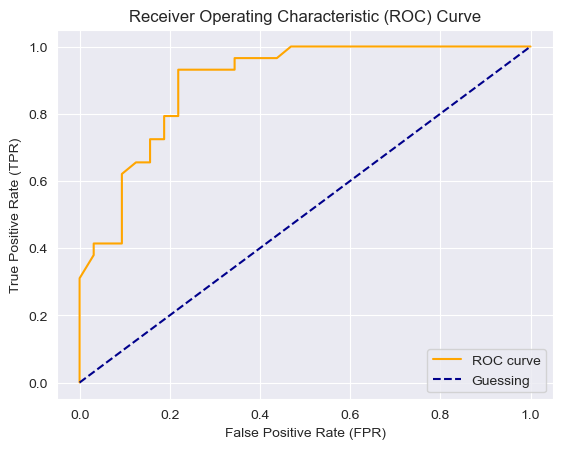

In [167]:
plot_roc_curve(fpr, tpr)

In [168]:
# Let's also look at the AUC score
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_probs_positive)

0.8933189655172414

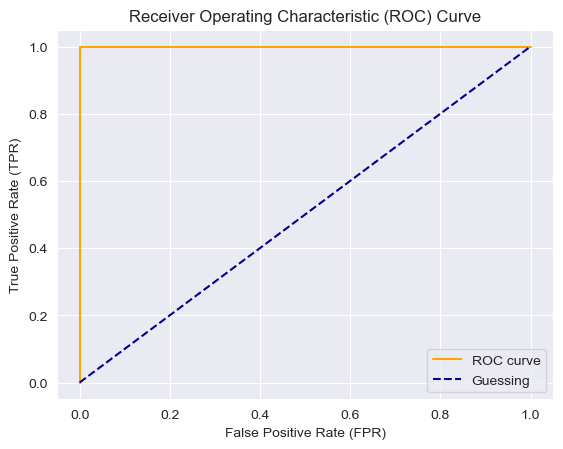

In [169]:
# Plot perfect ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_test)
plot_roc_curve(fpr, tpr)

In [170]:
# Similarly, the perfect AUC score is 1.0
roc_auc_score(y_test, y_test)

1.0

Our next evaluation tool, a **confusion matrix**

** Confusion Matrix **

A _confusion matrix_ is a quick way to compare

- The labels actually predicted by a model
- The labels it was supposed to predict

In other words, a _confusion matrix_ illustrates where the model
is confused.

In [171]:
# Let's get "hands on"
from sklearn.metrics import confusion_matrix

# Create a confusion matrix by making some predictions...
y_predictions = classifier.predict(X_test)

# ...and then creating a confusion matrix for those predictions
confusion_matrix(y_test, y_predictions)


array([[25,  7],
       [ 3, 26]])

In [172]:
# Visualize a confusion matrix with `pd.crosstab()`
pd.crosstab(y_test, y_predictions,
            rownames=['Actual Labels'],
            colnames=['Predicted Labels'])

Predicted Labels,0,1
Actual Labels,,
0,25,7
1,3,26


In [173]:
# Total all the labels and compare to our test set
25 + 7 + 3 + 26, len(X_test)

(61, 61)

In [174]:
# How to install a conda package into the current environment
# from **within** a Jupyter notebook
import sys
!conda install --yes seaborn

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/conda/base/context.py:201: FutureWarning: Adding 'defaults' to channel list implicitly is deprecated and will be removed in 25.3. 

To remove this warning, please choose a default channel explicitly with conda's regular configuration system, e.g. by adding 'defaults' to the list of channels:

  conda config --add channels defaults

For more information see https://docs.conda.io/projects/conda/en/stable/user-guide/configuration/use-condarc.html

  deprecated.topic(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/conda/base/context.py:201: FutureWarning: Adding 'defaults' to channel list implicitly is deprecated and will be removed in 25.3. 

To remove this warning, please choose a default channel explicitly with conda's regular configuration system, e.g. by adding 'defaults' to the list of channels:

  conda config --add channels defaults

For more information see https://docs.conda.io/projects/conda/e

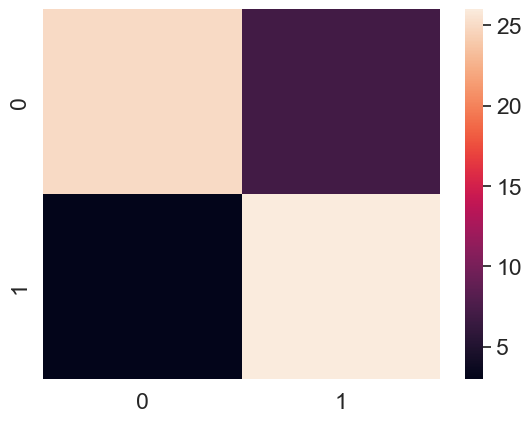

In [175]:
# Make our confusion matrix more visual with `seaborn`'s `heatmap()`
import seaborn as sns

# Set the font scale
sns.set(font_scale=1.5)

# Create a confusion matrix
conf_mat = confusion_matrix(y_test, y_predictions)

# Plot confusion matrix using heatmap
sns.heatmap(conf_mat)

plt.show()

** Confusion Matrix **

The next tool for evaluating a classification model is a
"confusion matrix."

A "confusion matrix" is a quick way to compare the

- Labels predicted by a model to
- The actual labels it was supposed to predict

In essence, this technique gives you an idea of where the model
is getting "confused."

In [176]:
# See [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
# for sklean confusion matrix.
from sklearn.metrics import confusion_matrix

y_predictions = classifier.predict(X_test)

# Remember, `y_test` captures the **actual** results and
# `y_predictions` captures the **model predictions**.
confusion_matrix(y_test, y_predictions)

array([[25,  7],
       [ 3, 26]])

In [177]:
pd.crosstab(y_test, y_predictions,
            rownames=['Actual Labels'],
            colnames=['Predicted Labels'])

Predicted Labels,0,1
Actual Labels,,
0,25,7
1,3,26


### Creating a confusion matrix using Scikit-Learn

To use the new methods (at the time of recording) of creating
a confusion matrix with Scikit-Learn, you will need `sklearn`
version 1.0 or greater.

In [178]:
sklearn.__version__

'1.5.1'

Newer versions (> 1.0) introduce two new methdos (functions?)

- `ConfusionMatrixDisplay.from_estimator()`
- `ConfusionMatrixDisplay.from_predictions()`

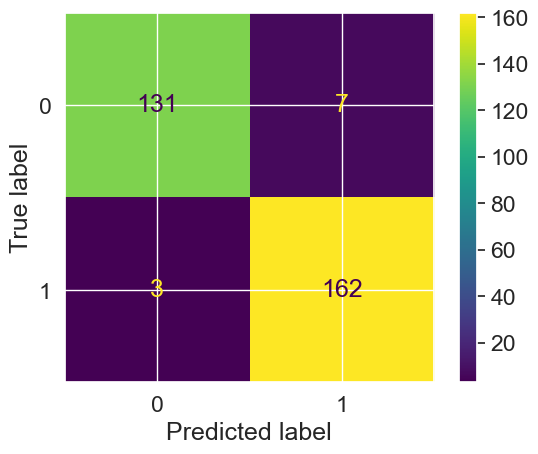

In [179]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(estimator=classifier, X=X, y=y)

plt.show()

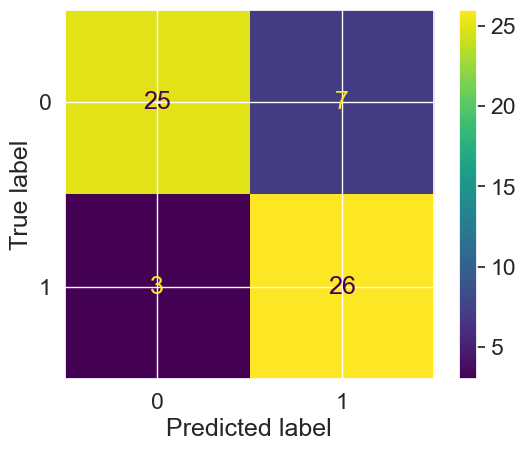

In [180]:
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_predictions,
)

plt.show()

**Classification Report**

In [181]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predictions))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



# Imagine a situation in which

- We test 10,000 people for a diseases
- But only 1 person actually has it

This situation is where precision and recall become valuable. In fact,
in this situation, **all** the metrics become valuable.

In [182]:
# Where precision and recall become valuable
disease_true = np.zeros(10000)
disease_true[0] = True # A 1

# Our model predicts 0 (False) for **every** case
disease_predictions = np.zeros(10000)

pd.DataFrame(classification_report(disease_true,
                                   disease_predictions,
                                   output_dict=True))

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000


### 4.2.2 Regression model evaluation metrics

[Regression model evaluation metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)

We're going to cover

1. R^2 (pronounced R-squared) or coefficient of determination
2. Mean absolute error (MAE)
3. Mean squared error (MSE)

In [183]:
from sklearn.ensemble import RandomForestRegressor

rng = np.random.default_rng(seed=42)

X = housing_df.drop('target', axis='columns')
y = housing_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=rng.integers(np.iinfo(np.uint32).max)
)

model = RandomForestRegressor(
    random_state=rng.integers(np.iinfo(np.uint32).max)
)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=3324115916)

In [184]:
model.score(X_test, y_test)

0.8109892899845894

In [185]:
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [186]:
y_test

9383     4.411
4455     1.538
5467     4.125
16034    2.386
9467     1.133
         ...  
5165     0.932
19186    2.211
12732    3.440
11287    2.146
8944     4.611
Name: target, Length: 4128, dtype: float64

In [187]:
y_test.mean()

2.087305479651163

In [188]:
from sklearn.metrics import r2_score

# Fill an array with `y_test.mean()`
y_test_mean = np.full(len(y_test), y_test.mean())

In [189]:
y_test_mean[:10]

array([2.08730548, 2.08730548, 2.08730548, 2.08730548, 2.08730548,
       2.08730548, 2.08730548, 2.08730548, 2.08730548, 2.08730548])

In [190]:
# Since the R^2 score evaluates the difference from the mean,
# we expect a score of 0.0
r2_score(y_true=y_test, y_pred=y_test_mean)

0.0

In [191]:
# Let's evaluate a "perfect" model
r2_score(y_true=y_test, y_pred=y_test)

1.0

In [192]:
from sklearn.metrics import mean_absolute_error

y_predictions = model.predict(X_test)
mean_absolute_error(y_true=y_test, y_pred=y_predictions)

0.3347121612403103

In [193]:
from sklearn.metrics import mean_squared_error

y_predictions = model.predict(X_test)
mean_squared_error(y_true=y_test, y_pred=y_predictions)

0.26390638010987644